In [41]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, GridSearchCV

# Random Forest model
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [42]:
import kagglehub
import os

print("kagglehub imported successfully!")

kagglehub imported successfully!


In [43]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download("lburleigh/asap-2-0")

print("Dataset downloaded to:")
print(path)

# Show files in the Kaggle ASAP 2.0 dataset
os.listdir(path)

# Loading the dataset
df = pd.read_csv(os.path.join(path, "ASAP2_train_sourcetexts.csv"))

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())

Dataset downloaded to:
C:\Users\marfo\.cache\kagglehub\datasets\lburleigh\asap-2-0\versions\8
               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  \
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
3  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   

In [44]:
columns_to_keep = [
    "essay_id",
    "score",
    "full_text",
    "assignment",
    "prompt_name"
]

df = df[columns_to_keep]

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())


df["full_text"] = df["full_text"].str.strip()
df["assignment"] = df["assignment"].str.strip()
df["prompt_name"] = df["prompt_name"].str.strip()

(df["full_text"] == "").sum()
df["score"].value_counts().sort_index()


               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
3  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
4  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  

<class 'pandas.DataFrame'

score
1    1751
2    6847
3    9021
4    5553
5    1356
6     200
Name: count, dtype: int64

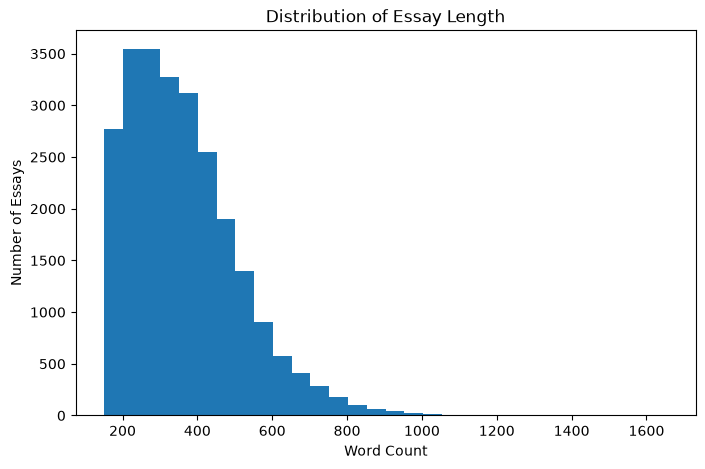

In [45]:
#Feature engineering
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))
df["word_count"].describe()


plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=30)
plt.xlabel("Word Count")
plt.ylabel("Number of Essays")
plt.title("Distribution of Essay Length")
plt.show()

In [46]:
df[df["word_count"] < 20]

df.to_csv("cleaned_asap.csv", index=False)
     

import re
#Feature engineering
df["character_count"] = df["full_text"].apply(len)

df["sentence_count"] = df["full_text"].apply(lambda x: len(re.findall(r"[.!?]+", x)))

df["avg_sentence_length"] = (df["word_count"] / df["sentence_count"])

df["unique_words"] = df["full_text"].apply(lambda x: len(set(x.lower().split())))


In [47]:
df.head()

,essay_id,score,full_text,assignment,prompt_name,word_count,character_count,sentence_count,avg_sentence_length,unique_words
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,396,2329,17,23.294118,218
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,200,1019,12,16.666667,118
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,371,2141,31,11.967742,205
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,224,1251,10,22.400000,130
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,219,1230,7,31.285714,134


In [48]:
# Type-Token Ratio (TTR)
# Measures how diverse the vocabulary is in an essay

df["type_token_ratio"] = df.apply(
    lambda row: row["unique_words"] / row["word_count"]
    if row["word_count"] != 0 else 0,
    axis=1
)

df["type_token_ratio"].describe()

count    24728.000000
mean         0.515147
std          0.074006
min          0.054952
25%          0.463312
50%          0.513333
75%          0.565217
max          0.782353
Name: type_token_ratio, dtype: float64

In [49]:
!pip install textstat

In [50]:
import textstat

In [51]:
# Flesch Reading Ease
df["flesch_reading_ease"] = df["full_text"].apply(
    textstat.flesch_reading_ease
)

# Flesch-Kincaid Grade Level
df["flesch_kincaid_grade"] = df["full_text"].apply(
    textstat.flesch_kincaid_grade
)

# Check the new features
df[[
    "flesch_reading_ease",
    "flesch_kincaid_grade"
]].describe()

,flesch_reading_ease,flesch_kincaid_grade
count,24728.000000,24728.000000
mean,63.409849,9.532290
std,15.888635,5.274198
min,-632.715455,-0.243810
25%,56.645274,7.472333
50%,64.399891,9.000649
75%,71.727028,10.731072
max,108.515000,279.136364


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Convert essay text into TF-IDF numerical features

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)


tfidf_features = tfidf.fit_transform(df["full_text"])

print(tfidf_features.shape)
tfidf_df = pd.DataFrame(
    tfidf_features.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

(24728, 5000)


,00,000,10,100,11,114,118,12,13,14,...,york,young,younger,youre,youth,zero,zone,zones,zoom,zygomatic
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
# Select numerical features

numerical_features = df[
    [
        "word_count",
        "character_count",
        "sentence_count",
        "avg_sentence_length",
        "unique_words",
        "type_token_ratio",
        "flesch_reading_ease",
        "flesch_kincaid_grade"
    ]
]

In [54]:
# Combine numerical features with TF-IDF features

final_features = pd.concat(
    [
        numerical_features.reset_index(drop=True),
        tfidf_df.reset_index(drop=True)
    ],
    axis=1
)

final_features.head()

,word_count,character_count,sentence_count,avg_sentence_length,unique_words,type_token_ratio,flesch_reading_ease,flesch_kincaid_grade,00,000,...,york,young,younger,youre,youth,zero,zone,zones,zoom,zygomatic
0,396,2329,17,23.294118,218,0.550505,49.408355,12.096309,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,200,1019,12,16.666667,118,0.590000,75.664821,6.701153,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,371,2141,31,11.967742,205,0.552561,69.497985,6.538875,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,224,1251,10,22.400000,130,0.580357,57.312097,10.755697,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,219,1230,7,31.285714,134,0.611872,49.006667,14.089656,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
final_features.shape

(24728, 5008)

In [56]:
# Features
X = final_features

# Target variable (essay score)
y = df["score"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (24728, 5008)
Target shape: (24728,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (19782, 5008)
Testing data: (4946, 5008)


In [58]:
from sklearn.ensemble import RandomForestRegressor
# Create baseline Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Random Forest model created!


In [59]:
# Find columns containing infinity values

inf_columns = X_train.columns[np.isinf(X_train).any()]

print(inf_columns)

Index(['avg_sentence_length'], dtype='str')


In [60]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [61]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [62]:
print(np.isinf(X_train).sum().sum())
print(X_train.isnull().sum().sum())

0
0


In [63]:
rf_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [64]:
# Make predictions on test data

y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[3.76 2.17 2.39 4.02 1.93 3.67 3.3  2.02 3.83 4.69]


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Squared Error: 0.39684247877072387
Mean Absolute Error: 0.4776081682167408
R² Score: 0.6274441265098791


In [66]:
from sklearn.metrics import cohen_kappa_score

# Round predictions because essay scores are whole numbers
y_pred_rounded = np.round(y_pred).astype(int)

# Calculate Quadratic Weighted Kappa
qwk = cohen_kappa_score(
    y_test,
    y_pred_rounded,
    weights="quadratic"
)

print("Quadratic Weighted Kappa (QWK):", qwk)

Quadratic Weighted Kappa (QWK): 0.7348918558677818


In [67]:
# Get feature importance scores

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features

feature_importance.head(20)

,Feature,Importance
1,character_count,0.552064
5,type_token_ratio,0.014772
3,avg_sentence_length,0.008011
6,flesch_reading_ease,0.007788
4335,sun,0.005428
0,word_count,0.004048
4,unique_words,0.003705
7,flesch_kincaid_grade,0.003286
4493,think,0.003165
2678,luke,0.002923


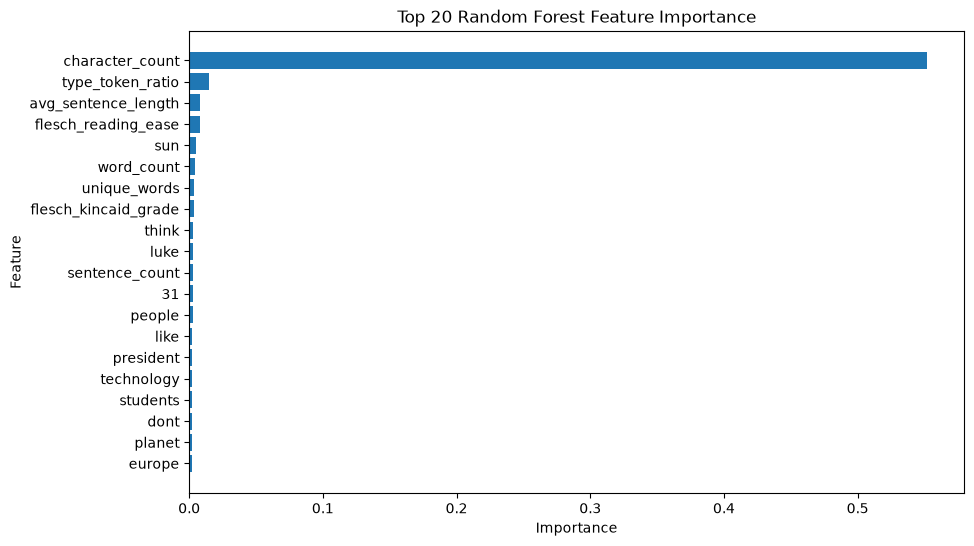

In [68]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(20)["Feature"],
    feature_importance.head(20)["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [69]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5]
}

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "RF_100_trees": RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),

    "RF_200_trees": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),

    "RF_depth20_leaf2": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

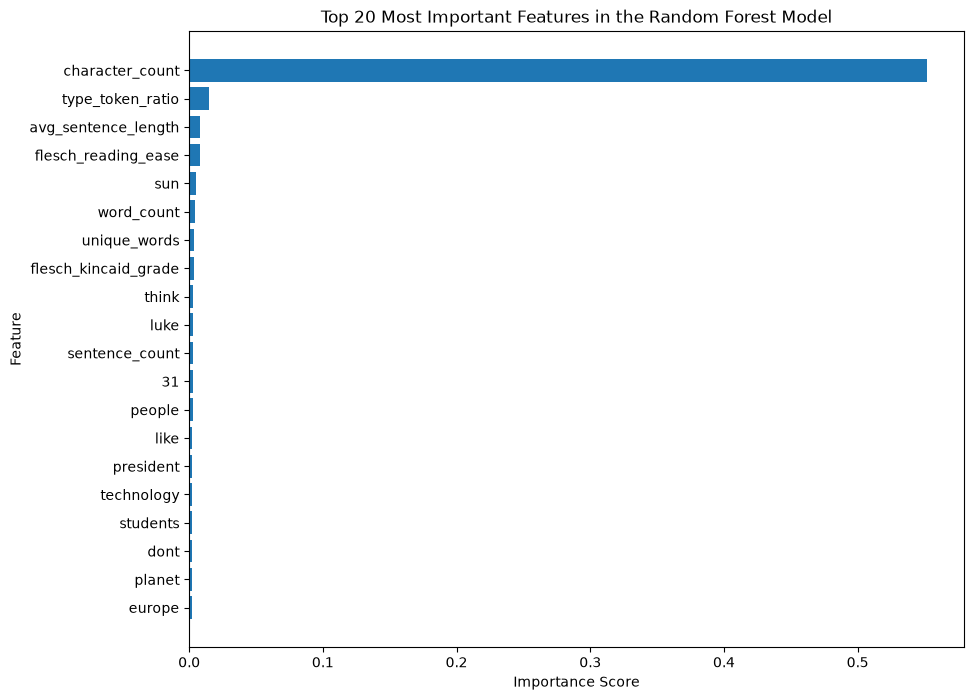

In [71]:
plt.figure(figsize=(10,8))

top20 = feature_importance.head(20)

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features in the Random Forest Model")

plt.gca().invert_yaxis()

plt.show()

In [72]:
results = pd.DataFrame({
    "Metric": [
        "Mean Squared Error (MSE)",
        "Mean Absolute Error (MAE)",
        "R² Score",
        "Quadratic Weighted Kappa (QWK)"
    ],
    "Value": [
        mse,
        mae,
        r2,
        qwk
    ]
})

results

,Metric,Value
0,Mean Squared Error (MSE),0.396842
1,Mean Absolute Error (MAE),0.477608
2,R² Score,0.627444
3,Quadratic Weighted Kappa (QWK),0.734892
